### Business Understanding

Objective

This project aims to help streaming platforms make **content acquisition decisions** by predicting whether a movie meets a predefined quality standard.

More specifically, the model is designed to support **content acquisition teams** that evaluate third-party movies and decide which titles are worth considering for licensing. Instead of predicting the exact Metacritic score, the problem is formulated as a **binary classification task**.

The target variable is derived from the Metacritic score:

* **1 — Acquisition-worthy:** Metacritic score ≥ 80
* **0 — Not acquisition-worthy:** Metacritic score < 80

The model therefore answers a practical business question:

> **"Is this movie likely to meet the minimum quality standard required for acquisition?"**

The classification output can then be used alongside other business considerations, such as licensing cost, available budget, genre strategy, and portfolio requirements, to support the final acquisition decision.

Business Decision Framework

The model does not replace the acquisition team's judgment. Instead, it acts as a **screening and decision-support tool** that identifies movies that are more likely to meet the predefined quality threshold.

A movie classified as acquisition-worthy can be prioritized for further evaluation, while a movie classified as not acquisition-worthy can receive lower priority.

Because the consequences of classification errors are asymmetric, the model should not be evaluated using accuracy alone.

False Negative

A false negative occurs when a movie that actually meets the quality threshold is classified as not acquisition-worthy.

This can result in an **opportunity cost**, as the platform may overlook a high-quality movie that could have strengthened its content portfolio.

False Positive

A false positive occurs when a movie that does not meet the quality threshold is classified as acquisition-worthy.

This may result in resources being spent evaluating or potentially licensing a lower-quality movie. However, the downside may be partially limited because the final acquisition decision can incorporate additional factors such as licensing costs, expected audience demand, and portfolio diversification.

Given these asymmetric consequences, **false negatives should receive particular attention during model evaluation**.

Classification Strategy

The primary objective is to correctly distinguish between movies that **meet the acquisition quality threshold** and those that do not.

The model produces a predicted probability of belonging to the acquisition-worthy class. Rather than relying exclusively on the default classification threshold of 0.50, the probability threshold can be adjusted using validation-set performance and business costs.

For example, if missing a high-quality movie is considered more costly than considering a mediocre movie, the classification threshold can be lowered to increase recall for the acquisition-worthy class.

The appropriate threshold should therefore be selected based on the business trade-off between false negatives and false positives rather than statistical accuracy alone.

Evaluation Framework

Because the target variable may be imbalanced, **accuracy is not considered the primary evaluation metric**.

The model will instead be evaluated using metrics that provide a better understanding of classification performance, including:

* **Precision** — proportion of movies classified as acquisition-worthy that actually meet the quality threshold.
* **Recall** — proportion of acquisition-worthy movies that the model successfully identifies.
* **F1-score** — harmonic mean of precision and recall.
* **PR-AUC** — overall performance across classification thresholds, particularly useful when the positive class is relatively rare.
* **Confusion Matrix** — to explicitly examine false positives and false negatives.
* **Cost-sensitive evaluation** — to assess performance under the assumption that false negatives and false positives have different business consequences.

The final model should therefore be selected based on its ability to provide a useful balance between identifying acquisition-worthy movies and limiting unnecessary acquisitions, rather than simply maximizing accuracy.


Small differences in the underlying Metacritic score near a boundary should therefore not automatically be interpreted as economically meaningful differences in movie quality.

Limitations

The classification framework has several important limitations.

Critics ≠ Viewers

Metacritic scores primarily reflect critical reception and may not accurately represent audience preferences.

Classification Label ≠ Watch Time

Meeting the Metacritic threshold does not imply that a movie will generate high viewing hours.

Classification Label ≠ Retention

A high-quality movie does not necessarily improve subscriber retention.

 Classification Label ≠ Revenue

The classification target is not a direct measure of profitability or financial return.

 Proxy Target

Metacritic-derived labels are used as an imperfect proxy for content quality because direct data on profitability, engagement, watch time, or retention is unavailable.

 Information Loss from Binarization

Converting a continuous Metacritic score into a binary target discards information.

For example, movies scoring 69 and 50 receive the same negative label, while movies scoring 70 and 95 receive the same positive label. Similarly, movies scoring 68 and 71 receive different labels despite having very similar scores.

Therefore, classification performance near the 70-point boundary should be interpreted carefully.

 Class Imbalance

If movies meeting the acquisition threshold represent a minority of the dataset, the target variable may be imbalanced. In this situation, accuracy can provide a misleading assessment of model performance.

Greater emphasis should therefore be placed on **precision, recall, F1-score, PR-AUC, and threshold-specific performance**.

 Probability Calibration

Predicted probabilities should not automatically be interpreted as exact probabilities of a movie being successful. If probability-based threshold selection is used, probability calibration should be evaluated to ensure that the predicted probabilities are sufficiently reliable for decision-making.

 Business Decision ≠ Model Prediction

The model provides a classification signal rather than an automatic acquisition recommendation.

The final decision should also consider factors such as:

* Licensing cost
* Available acquisition budget
* Target audience
* Genre and portfolio strategy
* Existing content library
* Geographic market
* Expected demand
* Contractual restrictions
* Strategic value of the movie

Therefore, the model should be considered a **decision-support system rather than an autonomous acquisition system**.

 Key Assumptions

The project implicitly assumes that:

1. Movies are evaluated **before acquisition and before release**, so only information available at the time of acquisition is used.
2. The features used by the model are available to the acquisition team before the acquisition decision.
3. Movie metadata contains sufficient information to provide some predictive signal about the probability of meeting the quality threshold.
4. Post-release information and popularity-derived variables are excluded to prevent **data leakage**.
5. The Metacritic threshold of 70 provides a meaningful operational definition of minimum acceptable quality.
6. The historical relationship between movie metadata and quality classification is sufficiently relevant to support predictions on future candidate movies.

 Overall Business Objective

The ultimate objective is to develop a classification model that can **identify movies that are likely to meet the platform's minimum quality standard**, allowing acquisition teams to prioritize promising titles for further financial and strategic evaluation.

The model is therefore not intended to predict profitability directly. Instead, it provides an initial **quality-based screening mechanism** that can make the content acquisition process more systematic, data-driven, and scalable.

### Libraries



In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import chisquare
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import VarianceThreshold
from collections import Counter
from sklearn.impute import KNNImputer
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import LabelEncoder  
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
import wn
from sklearn.dummy import DummyClassifier
from category_encoders import OneHotEncoder
from sklearn.impute import SimpleImputer
import nltk
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import make_scorer, recall_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import ConfusionMatrixDisplay

### Data Understanding


In [2]:
df = pd.read_csv('metacritic_movies.csv')

In [3]:
df.head()

,id,title,releaseDate,rating,genres,description,duration,tagline,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,production_companies,director,writer,top_cast
0,2000545497,Dekalog (1988),3/22/1996,TV-MA,Drama,This masterwork by Krzysztof Kieślowski is one...,572,NaN,100.0,13,Universal acclaim,75.0,224.0,Generally favorable,"Telewizja Polska (TVP),Zespol Filmowy ""Tor"",Se...",Krzysztof Kieslowski,"Krzysztof Kieslowski,Krzysztof Piesiewicz","Artur Barcis,Olgierd Lukaszewicz,Olaf Lubaszen..."
1,2000540575,Citizen Kane,9/4/1941,PG,"Drama,Mystery","Following the death of a publishing tycoon, ne...",119,Radio's Most Dynamic Artist . . The Man At Who...,100.0,19,Universal acclaim,83.0,991.0,Universal acclaim,"RKO Radio Pictures,Mercury Productions,RKO Rad...",Orson Welles,"Herman J. Mankiewicz,Orson Welles,John Housema...","Orson Welles,Joseph Cotten,Dorothy Comingore,A..."
2,2000542176,Boyhood,7/11/2014,R,Drama,"Filmed over 12 years with the same cast, Richa...",165,12 years in the making,100.0,50,Universal acclaim,76.0,2724.0,Generally favorable,"IFC Productions,Detour Filmproduction,IFC Film...",Richard Linklater,Richard Linklater,"Ellar Coltrane,Patricia Arquette,Ethan Hawke,E..."
3,2000521589,The Leopard (re-release),8/13/2004,PG,"Drama,History","Set in Sicily in 1860, Luchino Visconti's spec...",187,Luchino Visconti's Enduring Romantic Adventure,100.0,12,Universal acclaim,77.0,125.0,Generally favorable,"Titanus,Société Nouvelle Pathé Cinéma,Société ...",Luchino Visconti,"Giuseppe Tomasi di Lampedusa,Suso Cecchi D'Ami...","Burt Lancaster,Alain Delon,Claudia Cardinale,P..."
4,2000522553,The Godfather,3/24/1972,R,"Crime,Drama",Francis Ford Coppola's epic features Marlon Br...,175,An offer you can't refuse.,100.0,16,Universal acclaim,92.0,4355.0,Universal acclaim,"Paramount Pictures,Albert S. Ruddy Productions...",Francis Ford Coppola,"Mario Puzo,Francis Ford Coppola","Marlon Brando,Al Pacino,James Caan,Diane Keato..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16939 entries, 0 to 16938
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    16939 non-null  int64  
 1   title                 16939 non-null  object 
 2   releaseDate           16939 non-null  object 
 3   rating                12438 non-null  object 
 4   genres                16933 non-null  object 
 5   description           16939 non-null  object 
 6   duration              16939 non-null  int64  
 7   tagline               12058 non-null  object 
 8   metascore             16929 non-null  float64
 9   metascore_count       16939 non-null  int64  
 10  metascore_sentiment   16929 non-null  object 
 11  userscore             16923 non-null  float64
 12  userscore_count       16923 non-null  float64
 13  userscore_sentiment   13496 non-null  object 
 14  production_companies  16924 non-null  object 
 15  director           

In [5]:
df.isnull().sum()/len(df) * 100

id                       0.000000
title                    0.000000
releaseDate              0.000000
rating                  26.571817
genres                   0.035421
description              0.000000
duration                 0.000000
tagline                 28.815160
metascore                0.059035
metascore_count          0.000000
metascore_sentiment      0.059035
userscore                0.094457
userscore_count          0.094457
userscore_sentiment     20.325875
production_companies     0.088553
director                 0.059035
writer                   5.803176
top_cast                 0.867820
dtype: float64

In [6]:
df.duplicated(subset=["title"], keep="first").sum()

np.int64(620)

### Feature Engeneering


In [7]:
df['releaseDate'] = pd.to_datetime(df['releaseDate'], format="%m/%d/%Y", errors='coerce')

df['year'] = df['releaseDate'].dt.year
df['month'] = df['releaseDate'].dt.month
df['day'] = df['releaseDate'].dt.day

df.drop(columns=['releaseDate'], inplace=True)

In [8]:
df["is_good"] = df["metascore"].apply(lambda x: 1 if x >= 80 else 0)

### Data Cleaning

In [9]:
df.drop_duplicates(subset=["title","year"], keep="first", inplace=True)

In [10]:
df = df.drop(columns=['userscore', 'userscore_count', 'userscore_sentiment', 'metascore_sentiment', 'metascore_count']) # leakage columns
df = df.drop(columns=['id', 'title'])


Any post-release or popularity-derived features will be excluded to prevent leakage.|

In [11]:
df["day"] = df["day"].astype('Int64')
df["month"] = df["month"].astype('Int64')   
df["year"] = df["year"].astype('Int64') 
df["metascore"] = df["metascore"].astype('Int64')   

In [12]:
df.dropna(subset=["metascore"], axis=0, inplace=True)

### Univariate


In [134]:
df_vis= df.copy()
df_num = df_vis.select_dtypes(include=['int64', 'float64'])
df_cat = df_vis.select_dtypes(include=['object'])

In [135]:
for col in df_cat.columns:
    print("-"*50)
    print(f"Column: {col}")
    print("-"*50)
    print(df_cat[col].value_counts().head(20))


--------------------------------------------------
Column: rating
--------------------------------------------------
rating
R           6229
PG-13       3123
PG          1756
TV-MA        420
G            304
TV-PG        248
TV-14        237
TV-G          71
NC-17         32
TV-Y7          5
X              3
TV-Y           2
Approved       1
Name: count, dtype: int64
--------------------------------------------------
Column: description
--------------------------------------------------
description
The search for a missing woman unspools in two unexpectedly interconnected parts in Laura Citarella's playful new feature. The missing woman is Laura (Laura Paredes), a biologist cataloging plant species in and around the Argentinean city of Trenque Lauquen. The men searching for her: Rafael, her boyfriend, and Ezequiel, a coworker who has come to mean more to her in recent days. But in order to uncover the truth of Laura's disappearance, a profusion of mysteries must be explored. There's t

In [136]:
for col in df_cat.columns:
    print("-"*50)
    print(f"Column: {col}")
    print("-"*50)
    print(df_cat[col].value_counts(normalize=True).head(20))


--------------------------------------------------
Column: rating
--------------------------------------------------
rating
R           0.501086
PG-13       0.251227
PG          0.141260
TV-MA       0.033787
G           0.024455
TV-PG       0.019950
TV-14       0.019065
TV-G        0.005712
NC-17       0.002574
TV-Y7       0.000402
X           0.000241
TV-Y        0.000161
Approved    0.000080
Name: proportion, dtype: float64
--------------------------------------------------
Column: description
--------------------------------------------------
description
The search for a missing woman unspools in two unexpectedly interconnected parts in Laura Citarella's playful new feature. The missing woman is Laura (Laura Paredes), a biologist cataloging plant species in and around the Argentinean city of Trenque Lauquen. The men searching for her: Rafael, her boyfriend, and Ezequiel, a coworker who has come to mean more to her in recent days. But in order to uncover the truth of Laura's disappea

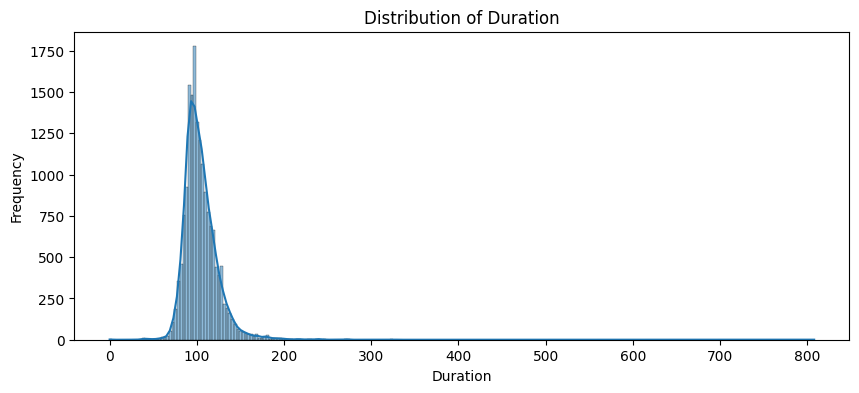

In [137]:
plt.figure(figsize=(10, 4))
sns.histplot(df_num["duration"].dropna(), kde=True)
plt.title(f'Distribution of Duration')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()

- Gaussian  distribution
- after log transformation the data spans from 3 top 6.5
- sharp spikes in the distribution, could be random noise or systematic as per standard movie release durations

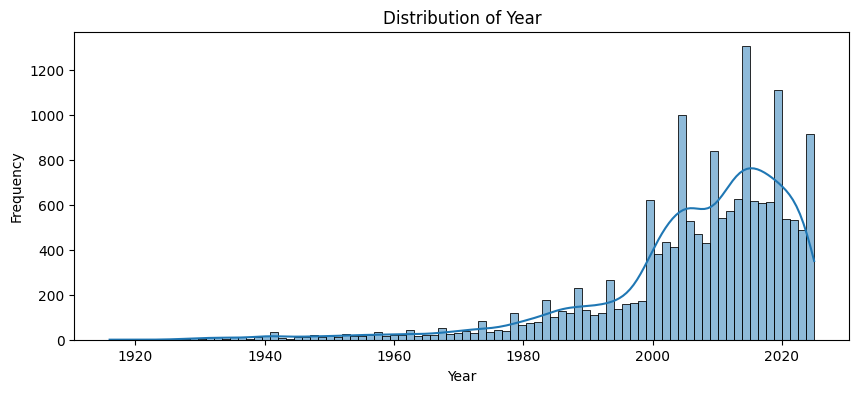

In [138]:
plt.figure(figsize=(10, 4))
sns.histplot(df_num["year"].dropna(), kde=True)
plt.title(f'Distribution of Year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

- more movies in later years(left skewed), showing an expanding industry
- this will pose a problem: I wanted to split based on release date, this will cause the trainning data to take in more recent movies which may hurt predictability

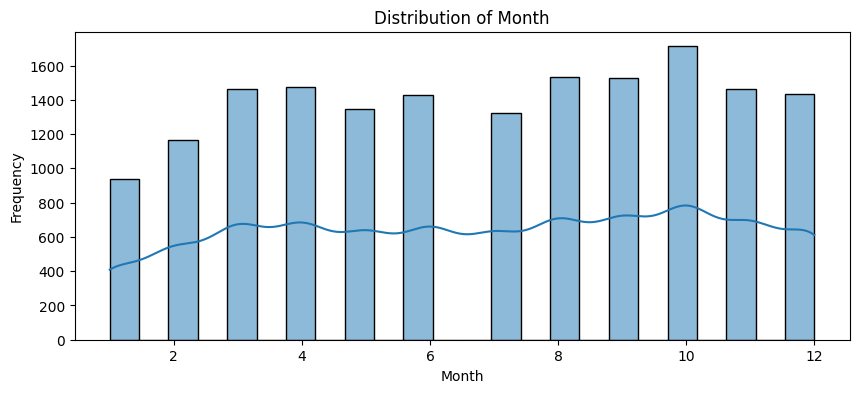

In [139]:
plt.figure(figsize=(10, 4))
sns.histplot(df_num["month"].dropna(), kde=True)
plt.title(f'Distribution of Month')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.show()

- Uniform distribution 


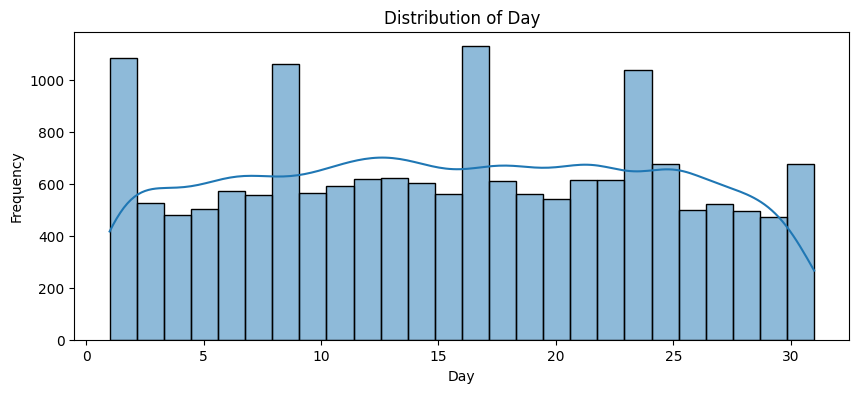

In [140]:
plt.figure(figsize=(10, 4))
sns.histplot(df_num["day"].dropna(), kde=True)
plt.title(f'Distribution of Day')
plt.xlabel('Day')
plt.ylabel('Frequency')
plt.show()

- Uniform distribution
- traces of seasonality every weekend

In [141]:
plt.figure(figsize=(10, 4))
fig = px.histogram(df_num["metascore"], nbins=150, title="Distribution of Metascore")
fig.update_xaxes(
    tickmode='linear',     # Linear tick spacing
    dtick=5,               # Tick every 10 units
    title='X Axis Label'
)



fig.update_traces(
    marker_line_width=1,
    marker_line_color="black"
)
fig.show()


<Figure size 1000x400 with 0 Axes>

- Left skewed
- Gaussian distribution
- concentration around the cutoff(70) which may cause imprecision in decisions

### Bivariate

In [142]:
for col in df_cat.columns:
    table = pd.crosstab(df_cat[col], df_num["is_good"], normalize='index') * 100
    table.rename(columns={0: 'Not Good', 1: 'Good'}, index={0: col, 1: col}, inplace=True)
    table = table.round(2)
    table["total"] = df_cat[col].value_counts()
    table["difference from mean"] = table["Good"] - df_num["is_good"].mean() * 100
    print("="*50)
    print(table)
    print("=" *50)
    print(df_cat[col].value_counts())
    print("="*50)

is_good   Not Good   Good  total  difference from mean
rating                                                
Approved    100.00   0.00      1            -12.113691
G            77.30  22.70    304             10.586309
NC-17        90.62   9.38     32             -2.733691
PG           88.61  11.39   1756             -0.723691
PG-13        93.15   6.85   3123             -5.263691
R            90.61   9.39   6229             -2.723691
TV-14        77.64  22.36    237             10.246309
TV-G         64.79  35.21     71             23.096309
TV-MA        85.95  14.05    420              1.936309
TV-PG        61.29  38.71    248             26.596309
TV-Y        100.00   0.00      2            -12.113691
TV-Y7        60.00  40.00      5             27.886309
X           100.00   0.00      3            -12.113691
rating
R           6229
PG-13       3123
PG          1756
TV-MA        420
G            304
TV-PG        248
TV-14        237
TV-G          71
NC-17         32
TV-Y7          

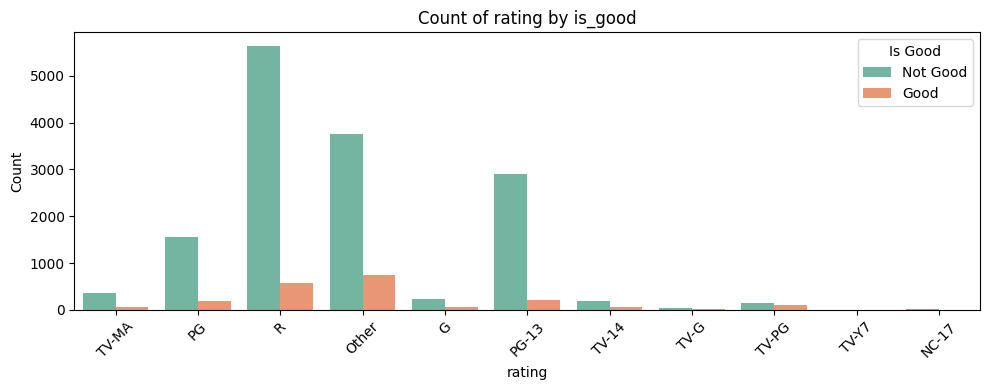

In [ ]:
for col in df_cat.columns:
    if df_vis[col].nunique() > 10:
        df_vis[col] = df_vis[col].apply(lambda x: x if x in df_vis[col].value_counts().nlargest(10).index else 'Other')
        plt.figure(figsize=(10, 4))
        sns.countplot(data=df_vis, x=col, hue="is_good", palette="Set2")
        plt.title(f'Count of {col} by is_good')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.legend(title='Is Good', loc='upper right', labels=['Not Good', 'Good'])
        plt.tight_layout()
        plt.show()

In [ ]:
signficant_featrures = []
for col in df_cat.columns:
    observed = pd.crosstab(df_cat[col], df_num["is_good"])
    print(f"Chi-square test for {col}:")
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)
    print("=" * 50)
    print(f"Chi-square test for {col}:")
    print("-" * 50)
    print(f"  Chi-square statistic: {chi2_stat}")
    print("-"*50)
    print(f"  Degrees of freedom: {dof}")
    print("-"*50)
    print(f"  P-value: {p_value}")
    print("="*50)
    if p_value < 0.05:
        print(f"  Result: Reject the null hypothesis. There is a significant association between {col} and is_good.")
        signficant_featrures.append(col)
    else:
        print(f"  Result: Fail to reject the null hypothesis. There is no significant association between {col} and is_good.")

print("\nSignificant features based on Chi-square test:")
print(signficant_featrures)


In [ ]:
df_num.dropna(inplace=True)
df_num.drop(columns=["metascore"], inplace=True)

In [ ]:
for col in df_num.columns:
    if col != "is_good":
        table = df_num.groupby("is_good")[col].agg(["mean", "median", "std", "min", "max"])
        print("="*50)
        print(f"Descriptive statistics for {col} by is_good:")
        print(table)
        print("="*50)

In [ ]:
for col in df_num.columns:
    if col != "is_good":
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=df_num, x="is_good", y=col, palette="Set2")
        plt.title(f'Boxplot of {col} by is_good')
        plt.xlabel('Is Good')
        plt.ylabel(col)
        plt.xticks([0, 1], ['Not Good', 'Good'])
        plt.tight_layout()
        plt.show()

In [ ]:
for col in df_num.columns:
    if col != "is_good":
        table = df_num.groupby("is_good")[col].agg(["mean", "median"])
        table["mean_diff"] = table["mean"] - df_num[col].mean()
        table["median_diff"] = table["median"] - df_num[col].median()
        print("="*50)
        print(f"Mean difference for {col} by is_good:")
        print(table["mean_diff"])
        print("="*50)
        print(f"Median difference for {col} by is_good:")
        print(table["median_diff"])
        print("="*50)


### Multivariate

In [ ]:
le = LabelEncoder()
df_heat_cat = df_cat.copy()
for col in df_heat_cat.columns:
    df_heat_cat[col] = le.fit_transform(df_heat_cat[col].astype(str))
df_heat = pd.concat([df_heat_cat, df_num], axis=1)

In [ ]:
plt.figure(figsize=(20, 20)) 
fig = sns.heatmap(df_heat.corr(), annot=True, cmap='coolwarm', fmt=".2f")
fig.set_title('Correlation Heatmap of Numerical and Categorical Features')
plt.show()

Most important features are duration, rating, genres, second genre.

### Data Split

In [13]:
x = df.drop(columns=['is_good', "metascore"])
y = df['is_good']

In [14]:
def train_val_test_time_split(X, y, date_column, train_size=0.8, val_size=0.1, test_size=0.1):
    """
    Create chronological train/validation/test splits from X and y
    
    Args:
        X: Features DataFrame
        y: Target Series/DataFrame
        date_column: Column in X containing release dates/years
        train_size: Proportion for training (oldest)
        val_size: Proportion for validation (middle)
        test_size: Proportion for testing (newest)
    """
    assert abs(train_size + val_size + test_size - 1.0) < 1e-10, "Sizes must sum to 1"
    
    # Combine X and y temporarily
    df = X.copy()
    df['target'] = y
    
    # Sort by date
    df_sorted = df.sort_values(date_column).reset_index(drop=True)
    n = len(df_sorted)
    
    # Calculate split indices
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    
    # Split
    train_df = df_sorted.iloc[:train_end].copy()
    val_df = df_sorted.iloc[train_end:val_end].copy()
    test_df = df_sorted.iloc[val_end:].copy()
    
    # Separate back into X and y
    x_train = train_df.drop('target', axis=1)
    y_train = train_df['target']
    x_val = val_df.drop('target', axis=1)
    y_val = val_df['target']
    x_test = test_df.drop('target', axis=1)
    y_test = test_df['target']
    
    print(f"Train: {train_df[date_column].min()} to {train_df[date_column].max()} ({len(train_df)} samples, {train_size*100:.0f}%)")
    print(f"Val:   {val_df[date_column].min()} to {val_df[date_column].max()} ({len(val_df)} samples, {val_size*100:.0f}%)")
    print(f"Test:  {test_df[date_column].min()} to {test_df[date_column].max()} ({len(test_df)} samples, {test_size*100:.0f}%)")
    
    return x_train, x_val, x_test, y_train, y_val, y_test

x_train, x_val, x_test, y_train, y_val, y_test = train_val_test_time_split(x, y, date_column=['year', "month", "day"])

Train: year     1916
month       1
day         1
dtype: Int64 to year     2019
month      12
day        31
dtype: Int64 (13538 samples, 80%)
Val:   year     2019
month       1
day         1
dtype: Int64 to year     2022
month      12
day        31
dtype: Int64 (1692 samples, 10%)
Test:  year     2022
month       1
day         1
dtype: Int64 to year     2025
month      12
day        31
dtype: Int64 (1693 samples, 10%)


### ML

In [15]:
numerical_features = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = x_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(numerical_features)
print(categorical_features)

['duration', 'year', 'month', 'day']
['rating', 'genres', 'description', 'tagline', 'production_companies', 'director', 'writer', 'top_cast']


In [16]:
# ============================================================
# Text preprocessing pipelines
# ============================================================
def create_text_pipeline(n_components):
    return Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='')),
        ('flatten', FunctionTransformer(
            lambda X: X.ravel()
        )),
        ("tfidf", TfidfVectorizer(
            max_df=0.5,
            stop_words="english"
        )),
        ("svd", TruncatedSVD(
            n_components=n_components,
            random_state=42
        ))
    ])


# Text features
writers_pipeline = create_text_pipeline(n_components=70)
cast_pipeline    = create_text_pipeline(n_components=70)
tag_pipeline     = create_text_pipeline(n_components=17)
desc_pipeline    = create_text_pipeline(n_components=70)
production_pipeline = create_text_pipeline(n_components=40)
director_pipeline = create_text_pipeline(n_components=25)
genres_pipeline = create_text_pipeline(n_components=10)
rating_pipeline = create_text_pipeline(n_components=5)

In [17]:
# 3. Assemble the Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), numerical_features),

        ('tag', tag_pipeline, ['tagline']),
        ('genres', genres_pipeline, ['genres']),
        ('desc', desc_pipeline, ['description']),
        ('cast', cast_pipeline, ['top_cast']),
        ('writers', writers_pipeline, ['writer']),
        ('production', production_pipeline, ['production_companies']),
        ('director', director_pipeline, ['director']),
        ('rating', rating_pipeline, ['rating'])
    ]
)
candidate_models = {
    'baseline_stratified': DummyClassifier(strategy='stratified', random_state=42),
    'baseline_most_frequent': DummyClassifier(strategy='most_frequent'),
    'logistic_regression': LogisticRegression(max_iter=1000, random_state=42),
    'decision_tree': DecisionTreeClassifier(random_state=42),
    'random_forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'gaussian_nb': GaussianNB(),
    'svc': SVC(probability=True, random_state=42),
    'xgboost': XGBClassifier(random_state=42, eval_metric='logloss'),
}

for model_name, model_obj in candidate_models.items():
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model_obj) 
    ])
    
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_val)
    train_accuracy = accuracy_score(y_train, pipeline.predict(x_train))
    train_precision = precision_score(y_train, pipeline.predict(x_train))
    train_recall = recall_score(y_train, pipeline.predict(x_train))
    train_f1 = f1_score(y_train, pipeline.predict(x_train))
    val_accuracy = accuracy_score(y_val, y_pred)
    val_precision = precision_score(y_val, y_pred)
    val_recall = recall_score(y_val, y_pred)
    val_f1 = f1_score(y_val, y_pred)

    print("="* 50)
    print(model_name)
    print("-" * 50)
    print(f"Training Accuracy: {train_accuracy:.2f}")
    print(f"Training Precision: {train_precision:.2f}")
    print(f"Training Recall: {train_recall:.2f}")
    print(f"Training F1 Score: {train_f1:.2f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}")
    print(f"Validation Precision: {val_precision:.2f}")
    print(f"Validation Recall: {val_recall:.2f}")
    print(f"Validation F1 Score: {val_f1:.2f}")
    print("="* 50)

baseline_stratified
--------------------------------------------------
Training Accuracy: 0.80
Training Precision: 0.11
Training Recall: 0.11
Training F1 Score: 0.11
Validation Accuracy: 0.77
Validation Precision: 0.14
Validation Recall: 0.11
Validation F1 Score: 0.12


c:\Users\mosta\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mosta\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


baseline_most_frequent
--------------------------------------------------
Training Accuracy: 0.89
Training Precision: 0.00
Training Recall: 0.00
Training F1 Score: 0.00
Validation Accuracy: 0.85
Validation Precision: 0.00
Validation Recall: 0.00
Validation F1 Score: 0.00
logistic_regression
--------------------------------------------------
Training Accuracy: 0.90
Training Precision: 0.67
Training Recall: 0.19
Training F1 Score: 0.29
Validation Accuracy: 0.86
Validation Precision: 0.63
Validation Recall: 0.05
Validation F1 Score: 0.09
decision_tree
--------------------------------------------------
Training Accuracy: 1.00
Training Precision: 1.00
Training Recall: 1.00
Training F1 Score: 1.00
Validation Accuracy: 0.81
Validation Precision: 0.28
Validation Recall: 0.19
Validation F1 Score: 0.23
random_forest
--------------------------------------------------
Training Accuracy: 1.00
Training Precision: 1.00
Training Recall: 1.00
Training F1 Score: 1.00
Validation Accuracy: 0.86
Validation

### Model tunning

In [18]:
# ============================================================
# 1. Build pipeline
# ============================================================

pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])


# ============================================================
# 2. Hyperparameter grid
# ============================================================

param_grid = {
    "model__var_smoothing": np.logspace(-12, -6, 13)
}


# ============================================================
# 3. Scoring metric
# ============================================================

scorer = make_scorer(
    recall_score,
    average="macro"
)


# ============================================================
# 4. Cross-validation
# ============================================================

cv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=scorer,
    n_jobs=-1,
    refit=True
)


# ============================================================
# 5. Fit GridSearchCV
# ============================================================

grid_search.fit(x_train, y_train)


# ============================================================
# 6. Get best model
# ============================================================

best_model = grid_search.best_estimator_


# ============================================================
# 7. Predictions
# ============================================================

y_train_pred = best_model.predict(x_train)
y_val_pred = best_model.predict(x_val)
y_test_pred = best_model.predict(x_test)


# ============================================================
# 8. Training metrics
# ============================================================

train_accuracy = accuracy_score(y_train, y_train_pred)

train_precision = precision_score(
    y_train,
    y_train_pred,
    zero_division=0
)

train_recall = recall_score(
    y_train,
    y_train_pred,
    zero_division=0
)

train_f1 = f1_score(
    y_train,
    y_train_pred,
    zero_division=0
)


# ============================================================
# 9. Validation metrics
# ============================================================

val_accuracy = accuracy_score(y_val, y_val_pred)

val_precision = precision_score(
    y_val,
    y_val_pred,
    zero_division=0
)

val_recall = recall_score(
    y_val,
    y_val_pred,
    zero_division=0
)

val_f1 = f1_score(
    y_val,
    y_val_pred,
    zero_division=0
)


# ============================================================
# 10. Test metrics
# ============================================================

test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)


# ============================================================
# 11. Results
# ============================================================

print("=== Best Parameters ===")
print(grid_search.best_params_)

print(f"\nBest CV Score (Macro Recall): "
      f"{grid_search.best_score_:.4f}")


print("\n=== Training Metrics ===")
print(f"Training Accuracy:  {train_accuracy:.4f}")
print(f"Training Precision: {train_precision:.4f}")
print(f"Training Recall:    {train_recall:.4f}")
print(f"Training F1 Score:  {train_f1:.4f}")


print("\n=== Validation Metrics ===")
print(f"Validation Accuracy:  {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")
print(f"Validation F1 Score:  {val_f1:.4f}")


print("\n=== Test Metrics ===")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1 Score:  {test_f1:.4f}")

=== Best Parameters ===
{'model__var_smoothing': np.float64(3.162277660168379e-08)}

Best CV Score (Macro Recall): 0.6244

=== Training Metrics ===
Training Accuracy:  0.6239
Training Precision: 0.1893
Training Recall:    0.7021
Training F1 Score:  0.2982

=== Validation Metrics ===
Validation Accuracy:  0.5219
Validation Precision: 0.2013
Validation Recall:    0.7621
Validation F1 Score:  0.3184

=== Test Metrics ===
Test Accuracy:  0.5003
Test Precision: 0.2054
Test Recall:    0.7816
Test F1 Score:  0.3254


{'model__var_smoothing': np.float64(3.162277660168379e-08)}


### Model evaluation


In [21]:
test_prob = best_model.predict_proba(x_test)[:, 1]
test_pred = best_model.predict(x_test)

print("=== Test Metrics ===")
print(f"ROC-AUC:   {roc_auc_score(y_test, test_prob):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision: {precision_score(y_test, test_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, test_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test, test_pred, zero_division=0):.4f}")
print(classification_report(y_test, test_pred, zero_division=0))

=== Test Metrics ===
ROC-AUC:   0.6778
Accuracy:  0.5003
Precision: 0.2054
Recall:    0.7816
F1:        0.3254
              precision    recall  f1-score   support

           0       0.92      0.45      0.60      1432
           1       0.21      0.78      0.33       261

    accuracy                           0.50      1693
   macro avg       0.56      0.62      0.46      1693
weighted avg       0.81      0.50      0.56      1693



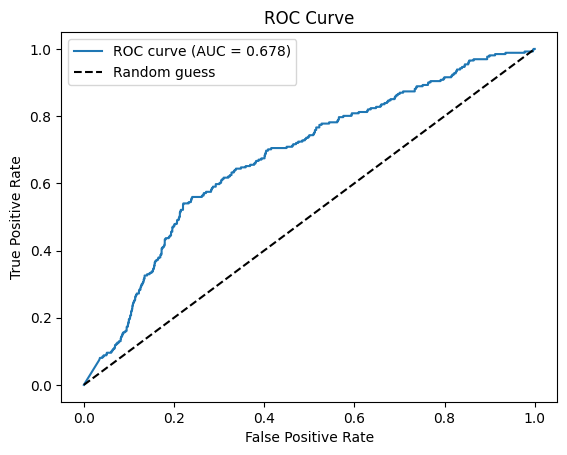

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve')
plt.legend()
plt.show()

In [24]:
cm = confusion_matrix(y_test, test_pred)

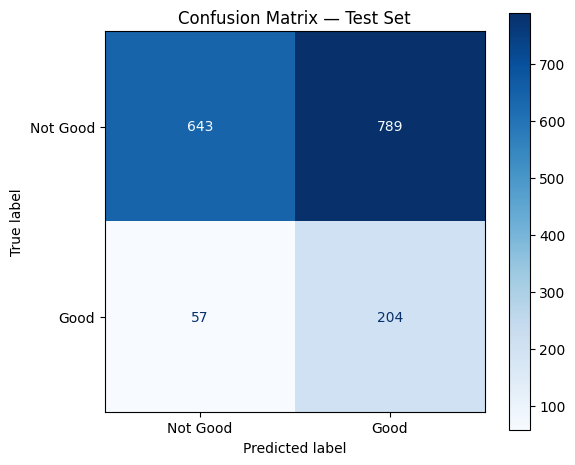

In [32]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels=["Class 0", "Class 1"], 
)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Good", "Good"]) 
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()
plt.show()


In [33]:
def evaluate_top_k(y_true, y_prob, k_percent=0.2):
    # Convert to DataFrame for easier handling
    df = pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob
    })

    # Sort by predicted probability descending
    df_sorted = df.sort_values(by="y_prob", ascending=False)

    # Determine K
    K = int(len(df_sorted) * k_percent)

    # Select top K
    top_k = df_sorted.iloc[:K]

    # Compute metrics
    true_positives_in_top_k = top_k["y_true"].sum()
    total_positives = df["y_true"].sum()
    baseline_rate = total_positives / len(df)

    precision_at_k = true_positives_in_top_k / K
    recall_at_k = true_positives_in_top_k / total_positives
    lift = precision_at_k / baseline_rate

    return {
        "K": K,
        "Precision_K": precision_at_k,
        "Recall_K": recall_at_k,
        "Lift": lift,
        "Baseline Positive Rate": baseline_rate
    }

# Get predicted probabilities for class 1
y_prob = best_model.predict_proba(x_test)[:, 1]

for k in [0.2]:
    results = evaluate_top_k(y_test, y_prob, k_percent=k)
    print(f"\nTop {int(k*100)}%")
    print(results)


Top 20%
{'K': 338, 'Precision_K': np.float64(0.29289940828402367), 'Recall_K': np.float64(0.3793103448275862), 'Lift': np.float64(1.8999183840032647), 'Baseline Positive Rate': np.float64(0.15416420555227406)}
